In [17]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time
from model_solver import MacrophageModel, Params

# Define a function to generate base parameters so we always start clean
def get_base_params(M=10, N=10, tol=1e-6):
    return Params(
        M=M, 
        N=N, 
        kplus=3, kminus=1, beta=2, D_min=0.1, gamma=0.2, sigma_b=0.004, sigma_max=0.4, 
        V_tot=100000, v_max=10, theta=10, tol=tol
    )

t_span = (0, 10.0)
t_eval = np.linspace(*t_span, 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Spatial Grid Independence ($M$)
We test whether the spatial resolution affects the final cell density profile. If the model is grid-independent, the curves for finer grids (higher $M$) should overlap.

In [ ]:
M_values = [25, 50, 100]

# Dictionary to just store the spatial arrays for each M
spatial_results = {}

for M in M_values:
    # 1. Setup model with current M
    p = get_base_params(M=M)
    model = MacrophageModel(p)
    
    # 2. Run simulation (starting with empty domain)
    u0 = np.zeros((M + 1, p.N + 1)).ravel()
    U, _ = model.solve(t_span, t_eval, y0=u0)
    
    # 3. Compute diagnostics
    diagnostics = model.compute_diagnostics(U)
    spatial_results[M] = diagnostics["spatial"]
    

--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------


<Figure size 800x500 with 0 Axes>

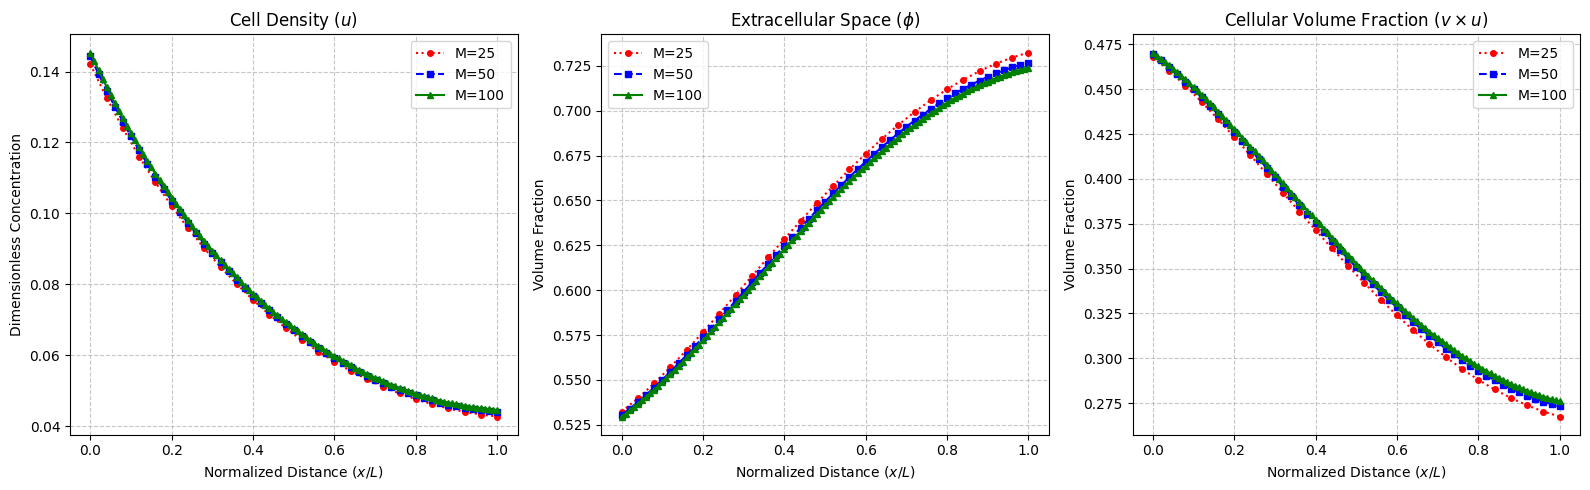

In [ ]:
# 3. Plot the Spatial Profiles Side-by-Side (WITH MARKERS)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {25: 'red', 50: 'blue', 100: 'green'}
line_styles = {25: ':', 50: '--', 100: '-'}
# NEW: Define a unique marker shape for each grid resolution
markers = {25: 'o', 50: 's', 100: '^'}  # Circle, Square, Triangle

for M in M_values:
    print(f"Simulating M = {M}...")
    normalized_x = np.linspace(0, 1.0, M + 1)
    
    u_profile = spatial_results[M]["cell_density"][-1, :]
    phi_profile = spatial_results[M]["phi"][-1, :]
    vu_profile = spatial_results[M]["volume_fraction"][-1, :]
    
    # Added marker and markersize to each plot
    axes[0].plot(normalized_x, u_profile, label=f'M={M}', 
                 color=colors[M], linestyle=line_styles[M], linewidth=1.5,
                 marker=markers[M], markersize=4)
    
    axes[1].plot(normalized_x, phi_profile, label=f'M={M}', 
                 color=colors[M], linestyle=line_styles[M], linewidth=1.5,
                 marker=markers[M], markersize=4)
    
    axes[2].plot(normalized_x, vu_profile, label=f'M={M}', 
                 color=colors[M], linestyle=line_styles[M], linewidth=1.5,
                 marker=markers[M], markersize=4)

# Format the plots
axes[0].set_title("Cell Density ($u$)")
axes[0].set_ylabel("Dimensionless Concentration")

axes[1].set_title(r"Extracellular Space ($\phi$)")
axes[1].set_ylabel("Volume Fraction")

axes[2].set_title("Cellular Volume Fraction ($v \\times u$)")
axes[2].set_ylabel("Volume Fraction")

for ax in axes:
    ax.set_xlabel("Normalized Distance ($x/L$)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Structure Grid Independence ($N$)
We test whether the lipid class resolution affects the final lipid distribution within the cells.

In [ ]:
N_values = [25, 50, 100]
structural_results = {}

for N in N_values:
    print(f"Simulating N = {N}...")
    p = get_base_params(N=N)
    model = MacrophageModel(p)
    
    u0 = np.zeros((p.M + 1, N + 1)).ravel()
    U, _ = model.solve(t_span, t_eval, y0=u0)
    
    diagnostics = model.compute_diagnostics(U)
    structural_results[N] = diagnostics["structure"]

--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------


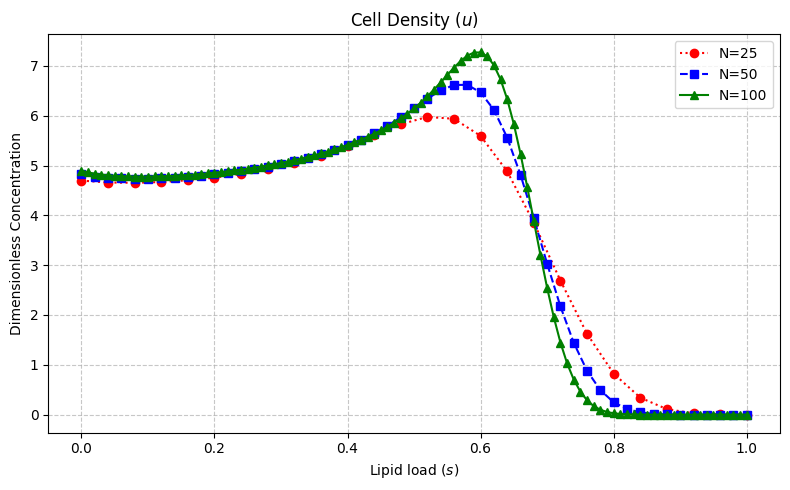

In [12]:
# Plot the Structure Profiles Side-by-Side (WITH MARKERS)
plt.figure(figsize=(8, 5))

colors = {25: 'red', 50: 'blue', 100: 'green'}
line_styles = {25: ':', 50: '--', 100: '-'}
markers = {25: 'o', 50: 's', 100: '^'}  # Circle, Square, Triangle

for N in N_values:
    s = np.linspace(0, 1.0, N + 1)
    
    u_profile = structural_results[N]["cell_density"][-1, :]
    
    # Added marker and markersize to each plot
    plt.plot(s, N*u_profile, label=f'N={N}', 
                 color=colors[N], linestyle=line_styles[N], linewidth=1.5,
                 marker=markers[N], markersize=6)


# Format the plots
plt.title("Cell Density ($u$)")
plt.ylabel("Dimensionless Concentration")
plt.xlabel("Lipid load ($s$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Solver Tolerance Sensitivity
We measure how the relative tolerance (`tol`) of the BDF solver impacts both execution time and the precision of the total macrophage count.

Tolerance       | Execution Time (s)   | Final Total Macrophages  
-----------------------------------------------------------------
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
1e-03           | 0.0529               | 7928.882468              
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
1e-04           | 0.0492               | 7928.906342              
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
1e-05           | 0.0550               | 7928.915663              
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------
1e-06           | 0.0696               | 7928.915787              
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constrai

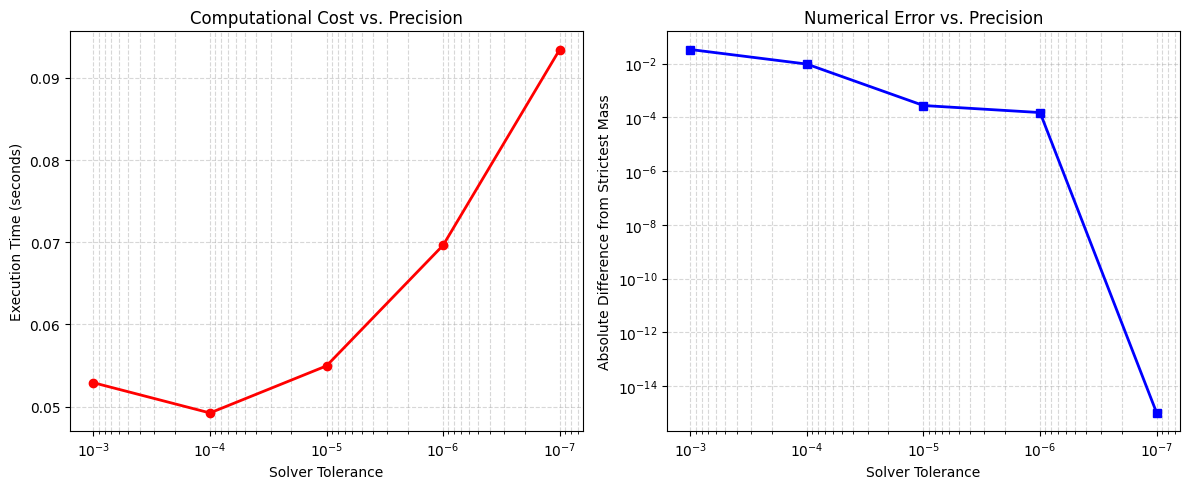

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt

# We use a slightly wider range of tolerances to get a good plot
tolerances = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

execution_times = []
final_masses = []

print(f"{'Tolerance':<15} | {'Execution Time (s)':<20} | {'Final Total Macrophages':<25}")
print("-" * 65)

# 1. Run the solver for each tolerance
for tol in tolerances:
    p = get_base_params(tol=tol)
    model = MacrophageModel(p)
    
    u0 = np.zeros((p.M + 1, p.N + 1)).ravel()
    
    start_time = time.time()
    U, _ = model.solve(t_span, t_eval, y0=u0)
    end_time = time.time()
    
    diagnostics = model.compute_diagnostics(U)
    final_total = diagnostics["totals"]["macrophage_number"][-1]
    
    elapsed = end_time - start_time
    execution_times.append(elapsed)
    final_masses.append(final_total)
    
    print(f"{tol:<15.0e} | {elapsed:<20.4f} | {final_total:<25.6f}")

# 2. Assume the strictest tolerance (1e-7) is our "Ground Truth"
ground_truth_mass = final_masses[-1]

# Calculate the absolute error for each run compared to the ground truth
errors = [abs(mass - ground_truth_mass) for mass in final_masses]

# 3. Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Execution Time
ax1.plot(tolerances, execution_times, marker='o', color='red', linewidth=2)
ax1.set_xscale('log')
ax1.invert_xaxis() # We invert so stricter tolerance (smaller number) is on the right
ax1.set_title("Computational Cost vs. Precision")
ax1.set_xlabel("Solver Tolerance")
ax1.set_ylabel("Execution Time (seconds)")
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Plot 2: Mass Error
# We replace exact 0.0 error with a tiny number so it plots on a log scale
safe_errors = [e if e > 0 else 1e-15 for e in errors] 
ax2.plot(tolerances, safe_errors, marker='s', color='blue', linewidth=2)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_xaxis()
ax2.set_title("Numerical Error vs. Precision")
ax2.set_xlabel("Solver Tolerance")
ax2.set_ylabel("Absolute Difference from Strictest Mass")
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()